In [1]:
import scanpy as sc
import numpy as np
import giniclust3 as gc

c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1086: NumbaDepreca

In [2]:
adataRaw = sc.read_h5ad("../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad")
adataRaw.var_names_make_unique
adataRaw

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [3]:
sc.pp.filter_cells(adataRaw, min_genes=3)
sc.pp.filter_genes(adataRaw, min_cells=200)

# adataSC = anndata.AnnData(X=adataRaw.X.T, obs=adataRaw.var, var=adataRaw.obs)
adataRaw.X = adataRaw.X.toarray()

sc.pp.normalize_per_cell(adataRaw, counts_per_cell_after=1e4)

In [4]:
# Gini聚类
gc.gini.calGini(adataRaw)
adataGini = gc.gini.clusterGini(adataRaw, neighbors=3)

# Fano聚类
gc.fano.calFano(adataRaw)
adataFano = gc.fano.clusterFano(adataRaw)

Gene number is 9396
Cell number is 5227


In [5]:
consensusCluster = {}
consensusCluster["giniCluster"] = np.array(adataRaw.obs["rare"].values.tolist())
consensusCluster["fanoCluster"] = np.array(adataRaw.obs["fano"].values.tolist())

gc.consensus.generateMtilde(consensusCluster)
gc.consensus.clusterMtilde(consensusCluster)

# 获取最终的聚类结果
adataRaw.obs["final"] = consensusCluster["finalCluster"]

In [6]:
# 计算每个簇的细胞数量
cluster_counts = adataRaw.obs["final"].value_counts()

# 计算5%阈值
threshold = 0.05 * adataRaw.shape[0]

# 识别小于5%细胞数量的簇
rare_clusters = cluster_counts[cluster_counts < threshold].index

# 获取属于稀有簇的细胞索引
rare_cells = adataRaw.obs[adataRaw.obs["final"].isin(rare_clusters)].index

# 保存稀有细胞的索引到CSV文件
# rare_cells.to_series().to_csv("scCAD_rare_cells_indices.csv", index=False)


# 添加稀有细胞标签
adataRaw.obs["rare_cells"] = "non-rare"
adataRaw.obs.loc[rare_cells, "rare_cells"] = "rare"

In [9]:
adataRaw.obs['rare_cells'].to_csv("GiniClust3_rare_cells_indices.csv", index=False)

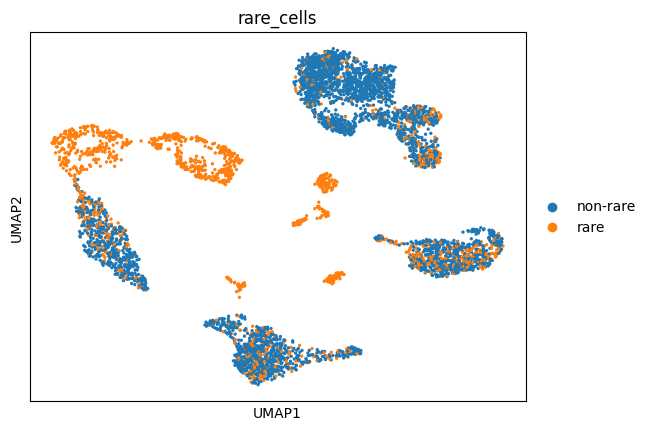

In [8]:
# 标准化和PCA降维
sc.pp.scale(adataRaw)  # 对数据进行标准化
sc.tl.pca(adataRaw, svd_solver='arpack')  # 运行PCA
# 使用UMAP可视化稀有细胞群
sc.pp.neighbors(adataRaw, use_rep="X_pca")  # 计算近邻图
sc.tl.umap(adataRaw)  # 运行UMAP
sc.pl.umap(adataRaw, color="rare_cells")  # 可视化稀有细胞群